In [3]:
import matplotlib.pyplot as plt

In [4]:
KEYS = ["COMET", "MetricX", "BLEURT", "BLEU"]

# Main Figure

In [35]:
def plot_main_figure(data, save_key="main_figure"):
    """
    Plot a 3x4 grid figure:
    - 3 rows: En-Zh, En-De, En-Ja (language directions)
    - 4 columns: COMET, MetricX, BLEURT, BLEU (metrics)
    
    Data structure expected:
    data = {
        'En-Zh': {
            'SFT': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
            'HPO': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
            'Offline (utterance)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'Offline (long-form)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float}
        },
        'En-De': { ... },
        'En-Ja': { ... }
    }
    """
    
    # Define the layout
    metrics = ["COMET", "MetricX", "BLEURT", "BLEU"] 
    languages = ["En-Zh", "En-De", "En-Ja"]
    methods = ["SFT", "HPO"]
    offline_methods = ["Offline (utterance)", "Offline (long-form)"]
    
    # Create the figure with 3 rows and 4 columns
    fig, axes = plt.subplots(3, 4, figsize=(16, 12), dpi=100)
    
    # Colors and styles for the methods
    colors = {'SFT': 'blue', 'HPO': 'red'}
    markers = {'SFT': 'o', 'HPO': 's'}
    offline_colors = {'Offline (utterance)': 'green', 'Offline (long-form)': 'orange'}
    offline_linestyles = {'Offline (utterance)': '--', 'Offline (long-form)': '-.'}
    
    # Plot each subplot
    for row, lang in enumerate(languages):
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            
            # Check if language data exists
            if lang in data:
                # Plot each method (SFT and HPO curves)
                for method in methods:
                    if method in data[lang]:
                        method_data = data[lang][method]
                        if 'LAAL' in method_data and metric in method_data:
                            laal_values = method_data['LAAL']
                            metric_values = method_data[metric]
                            
                            # Plot the curve
                            ax.plot(laal_values, metric_values, 
                                   label=method, 
                                   color=colors[method], 
                                   marker=markers[method], 
                                   markersize=6,
                                   linewidth=2)
                
                # Plot offline baselines as horizontal lines
                for offline_method in offline_methods:
                    if offline_method in data[lang]:
                        offline_data = data[lang][offline_method]
                        if metric in offline_data:
                            metric_value = offline_data[metric]
                            
                            # Plot horizontal line
                            ax.axhline(y=metric_value, 
                                      color=offline_colors[offline_method], 
                                      linestyle=offline_linestyles[offline_method],
                                      linewidth=2,
                                      label=offline_method,
                                      alpha=0.8)
            
            # Set titles and labels
            if row == 0:  # Top row gets metric labels
                ax.set_title(metric, fontsize=18, fontweight='bold')
            
            if col == 0:  # Left column gets language labels
                ax.set_ylabel(lang, fontsize=16, fontweight='bold')
            
            if row == 2:  # Bottom row gets x-axis labels
                ax.set_xlabel('LAAL (ms)', fontsize=16)
            
            # Add grid and set tick label font sizes
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Adjust layout to prevent overlap and make room for legend
    plt.tight_layout()
    
    # Create a single legend at the bottom center of the entire figure
    handles, labels = [], []
    
    # Collect legend elements from all methods
    method_handles = [
        plt.Line2D([0], [0], color='blue', marker='o', linestyle='-', markersize=6, linewidth=2, label='SFT'),
        plt.Line2D([0], [0], color='red', marker='s', linestyle='-', markersize=6, linewidth=2, label='HPO'),
        plt.Line2D([0], [0], color='green', linestyle='--', linewidth=2, label='Offline (utterance)'),
        plt.Line2D([0], [0], color='orange', linestyle='-.', linewidth=2, label='Offline (long-form)')
    ]
    
    # Add the legend at the bottom center
    fig.legend(handles=method_handles, 
               loc='lower center', 
               bbox_to_anchor=(0.5, -0.02), 
               ncol=4, 
               fontsize=14,
               frameon=True,
               fancybox=False,
               shadow=False)
    
    # Adjust layout again to accommodate legend
    plt.subplots_adjust(bottom=0.1)
    
    # Save the figure
    plt.savefig(f"plots/{save_key}.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    return fig, axes

In [123]:
# Example usage and data structure
import numpy as np

# Example data structure - replace this with your actual data
example_data = {
    'En-Zh': {
        'SFT': {
            'LAAL': [1216, 1740, 2305, 2741],
            'COMET': [0.7348, 0.7656, 0.7903, 0.7954],
            'MetricX': [-4.52, -4.23, -3.8, -3.55],
            'BLEURT': [0.6255, 0.6463, 0.6608, 0.6658],
            'BLEU': [44.5, 47.59, 48.2, 48]
        },
        'HPO': {
            'LAAL': [1383, 1895, 2303, 2439],
            'COMET': [0.8234, 0.8295, 0.8459, 0.837],
            'MetricX': [-3.21, -3.08, -2.66, -2.83],
            'BLEURT': [0.6619, 0.6778, 0.6848, 0.6778],
            'BLEU': [43.37, 47.35, 45.86, 44.9]
        },
        'Offline (utterance)': {
            'COMET': 0.8223,
            'MetricX': -3.15,
            'BLEURT': 0.6786,
            'BLEU': 48.49
        },
        'Offline (long-form)': {
            'COMET': 0.8516,
            'MetricX': -2.7,
            'BLEURT': 0.6983,
            'BLEU': 49.41
        }
    },
    'En-De': {
        'SFT': {
            'LAAL': [1063, 1773, 2192, 2912],
            'COMET': [0.8625, 0.8849, 0.8865, 0.8904],
            'MetricX': [-4.59, -3.68, -3.52, -3.32],
            'BLEURT': [0.6226, 0.6539, 0.6629, 0.669],
            'BLEU': [24.57, 27.56, 30.2, 29.4]
        },
        'HPO': {
            'LAAL': [1569, 1898, 2293, 2902],
            'COMET': [0.9109, 0.9148, 0.9179, 0.9109],
            'MetricX': [-2.77, -2.54, -2.48, -2.64],
            'BLEURT': [0.686, 0.6923, 0.6923, 0.6943],
            'BLEU': [27.04, 26.76, 28.62, 27.81]
        },
        'Offline (utterance)': {
            'COMET': 0.8851,
            'MetricX': -3.54,
            'BLEURT': 0.6721,
            'BLEU': 30.42
        },
        'Offline (long-form)': {
            'COMET': 0.9011,
            'MetricX': -3.1,
            'BLEURT': 0.7005,
            'BLEU': 30.57
        }
    },
    'En-Ja': {
        'SFT': {
            'LAAL': [1439, 2032, 2567, 3181],
            'COMET': [0.6383, 0.7053, 0.7501, 0.7497],
            'MetricX': [-6.2, -5.49, -5.13, -5.43],
            'BLEURT': [0.57, 0.611, 0.63, 0.6237],
            'BLEU': [23.9, 26.93, 28.77, 29.43]
        },
        'HPO': {
            'LAAL': [1948, 2424, 2697, 2968],
            'COMET': [0.7828, 0.7887, 0.781, 0.8035],
            'MetricX': [-4.45, -4.57, -4.42, -4.22],
            'BLEURT': [0.6497, 0.6456, 0.6492, 0.6519],
            'BLEU': [26.22, 26.79, 27.26, 26.85]
        },
        'Offline (utterance)': {
            'COMET': 0.7693,
            'MetricX': -4.85,
            'BLEURT': 0.6367,
            'BLEU': 30.88
        },
        'Offline (long-form)': {
            'COMET': 0.8073,
            'MetricX': -4.36,
            'BLEURT': 0.6638,
            'BLEU': 30.89
        }
    }
}


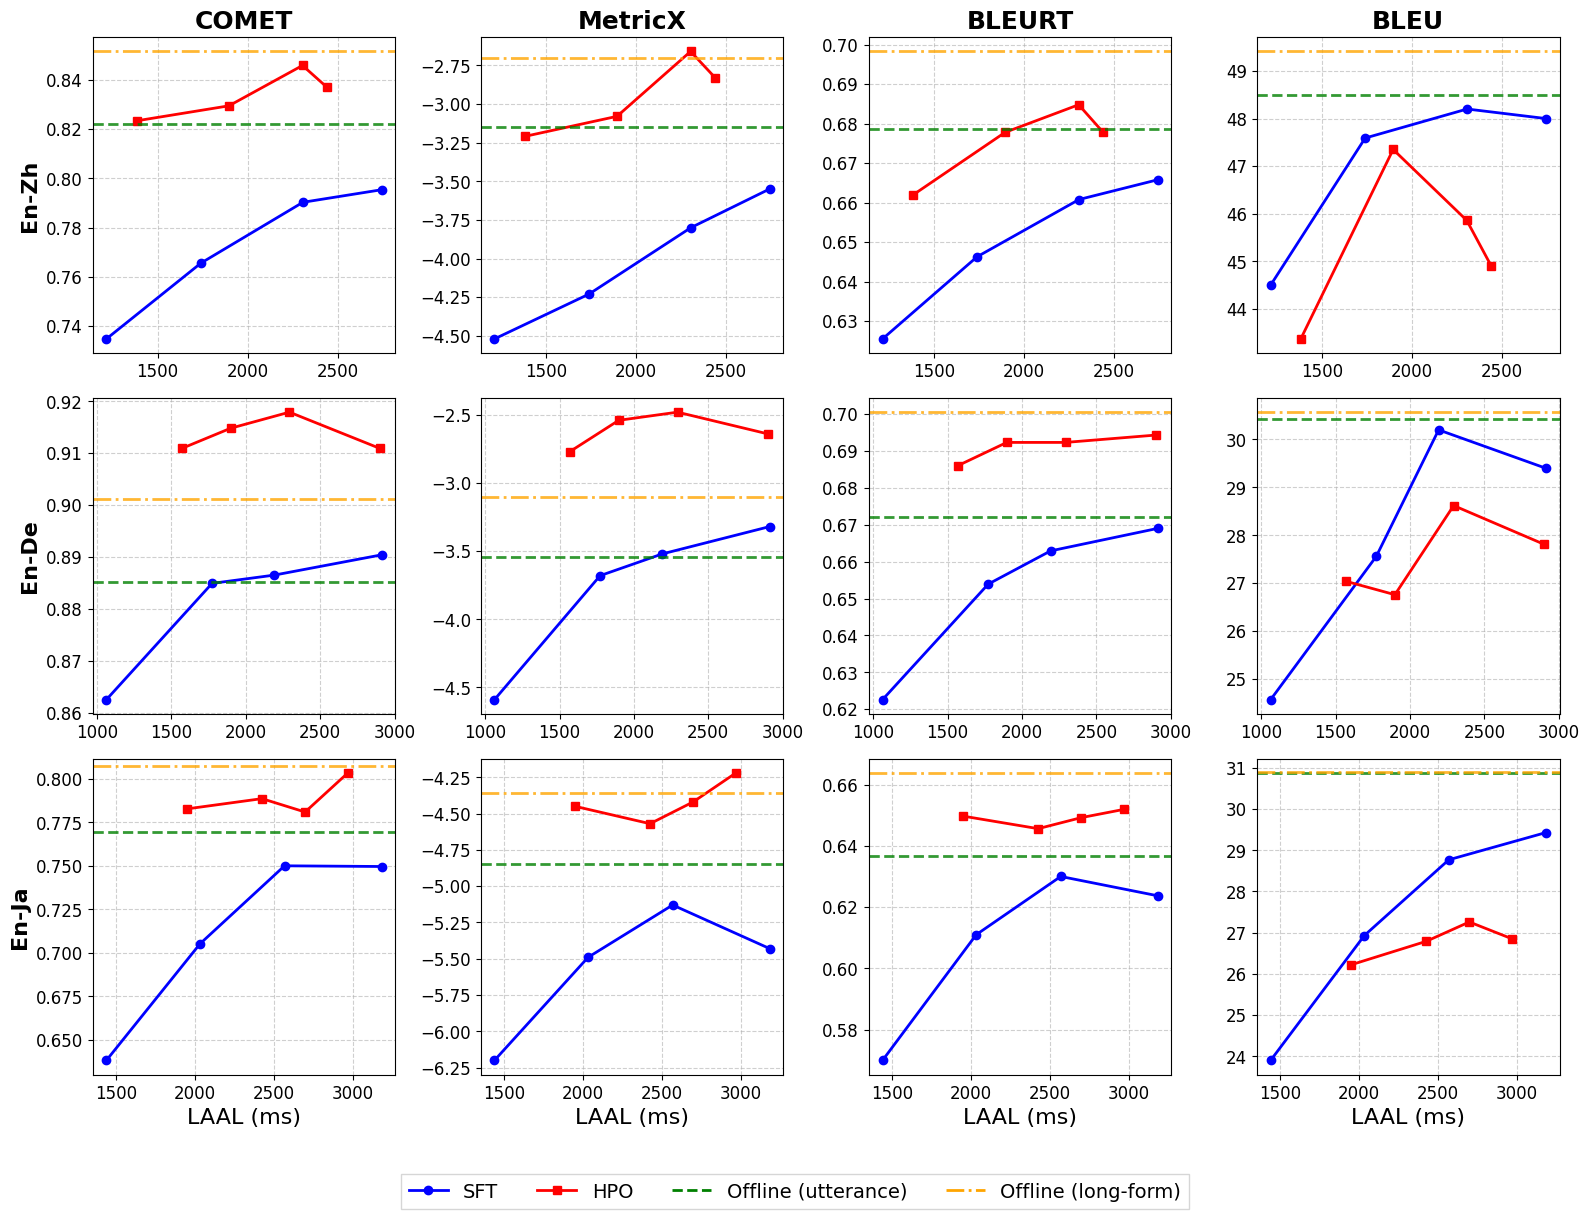

Main figure saved as 'plots/main_figure_example.pdf'
Figure structure: 3 rows (language directions) x 4 columns (metrics)
Blue circles = SFT, Red squares = HPO
Green dashed lines = Offline (utterance), Orange dash-dot lines = Offline (long-form)


In [124]:
# Generate the main figure
fig, axes = plot_main_figure(example_data, save_key="main_acl6060")

print("Main figure saved as 'plots/main_figure_example.pdf'")
print("Figure structure: 3 rows (language directions) x 4 columns (metrics)")
print("Blue circles = SFT, Red squares = HPO")
print("Green dashed lines = Offline (utterance), Orange dash-dot lines = Offline (long-form)")


# RealSI Dataset Figure - 1x4 Grid (En-Zh only)


In [5]:
def plot_realsi_figure(data, save_key="realsi_figure"):
    """
    Plot a 1x4 grid figure for RealSI dataset (En-Zh only):
    - 1 row: En-Zh (language direction)
    - 4 columns: COMET, MetricX, BLEURT, BLEU (metrics)
    
    Data structure expected:
    data = {
        'En-Zh': {
            'SFT': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
            'HPO': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
            'Offline (utterance)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'Offline (long-form)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float}
        }
    }
    """
    
    # Define the layout
    metrics = ["COMET", "MetricX", "BLEURT", "BLEU"] 
    lang = "En-Zh"  # Only En-Zh for RealSI
    methods = ["SFT", "HPO"]
    offline_methods = ["Offline (utterance)", "Offline (long-form)"]
    
    # Create the figure with 1 row and 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=100)
    
    # Colors and styles for the methods
    colors = {'SFT': 'blue', 'HPO': 'red'}
    markers = {'SFT': 'o', 'HPO': 's'}
    offline_colors = {'Offline (utterance)': 'green', 'Offline (long-form)': 'orange'}
    offline_linestyles = {'Offline (utterance)': '--', 'Offline (long-form)': '-.'}
    
    # Plot each subplot
    for col, metric in enumerate(metrics):
        ax = axes[col]
        
        # Check if language data exists
        if lang in data:
            # Plot each method (SFT and HPO curves)
            for method in methods:
                if method in data[lang]:
                    method_data = data[lang][method]
                    if 'LAAL' in method_data and metric in method_data:
                        laal_values = method_data['LAAL']
                        metric_values = method_data[metric]
                        
                        # Plot the curve
                        ax.plot(laal_values, metric_values, 
                               label=method, 
                               color=colors[method], 
                               marker=markers[method], 
                               markersize=6,
                               linewidth=2)
            
            # Plot offline baselines as horizontal lines
            for offline_method in offline_methods:
                if offline_method in data[lang]:
                    offline_data = data[lang][offline_method]
                    if metric in offline_data:
                        metric_value = offline_data[metric]
                        
                        # Plot horizontal line
                        ax.axhline(y=metric_value, 
                                  color=offline_colors[offline_method], 
                                  linestyle=offline_linestyles[offline_method],
                                  linewidth=2,
                                  label=offline_method,
                                  alpha=0.8)
        
        # Set titles and labels
        ax.set_title(metric, fontsize=18, fontweight='bold')
        
        # Only add language label to the leftmost subplot (matching main figure style)
        if col == 0:
            ax.set_ylabel(lang, fontsize=16, fontweight='bold')
        
        ax.set_xlabel('LAAL (ms)', fontsize=16)
        
        # Add grid and set tick label font sizes
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Adjust layout to prevent overlap and make room for legend
    plt.tight_layout()
    
    # Create a single legend at the bottom center of the entire figure
    method_handles = [
        plt.Line2D([0], [0], color='blue', marker='o', linestyle='-', markersize=6, linewidth=2, label='SFT'),
        plt.Line2D([0], [0], color='red', marker='s', linestyle='-', markersize=6, linewidth=2, label='HPO'),
        plt.Line2D([0], [0], color='green', linestyle='--', linewidth=2, label='Offline (utterance)'),
        plt.Line2D([0], [0], color='orange', linestyle='-.', linewidth=2, label='Offline (long-form)')
    ]
    
    # Add the legend at the bottom center
    fig.legend(handles=method_handles, 
               loc='lower center', 
               bbox_to_anchor=(0.5, -0.15), 
               ncol=4, 
               fontsize=14,
               frameon=True,
               fancybox=False,
               shadow=False)
    
    # Adjust layout again to accommodate legend
    plt.subplots_adjust(bottom=0.2)
    
    # Save the figure
    plt.savefig(f"plots/{save_key}.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    return fig, axes


In [6]:
# Example data for RealSI dataset (En-Zh only)
realsi_data = {
    'En-Zh': {
        'SFT': {
            'LAAL': [1339, 1911, 2391, 2836],
            'COMET': [0.6484, 0.6961, 0.7006, 0.7082],
            'MetricX': [-5.22, -4.71, -4.81, -4.76],
            'BLEURT': [0.5415, 0.5668, 0.5751, 0.5788],
            'BLEU': [22.76, 26.38, 26.39, 26.41]
        },
        'HPO': {
            'LAAL': [1676, 1995, 2372, 2528],
            'COMET': [0.7205, 0.7279, 0.7324, 0.7304],
            'MetricX': [-4.28, -4.35, -4.03, -4.2],
            'BLEURT': [0.5929, 0.591, 0.605, 0.5968],
            'BLEU': [26.08, 25.24, 25.32, 25.46]
        },
        'Offline (utterance)': {
            'COMET': 0.7523,
            'MetricX': -3.61,
            'BLEURT': 0.6064,
            'BLEU': 26.83
        },
        'Offline (long-form)': {
            'COMET': 0.7961,
            'MetricX': -3.29,
            'BLEURT': 0.6356,
            'BLEU': 27.94
        }
    }
}


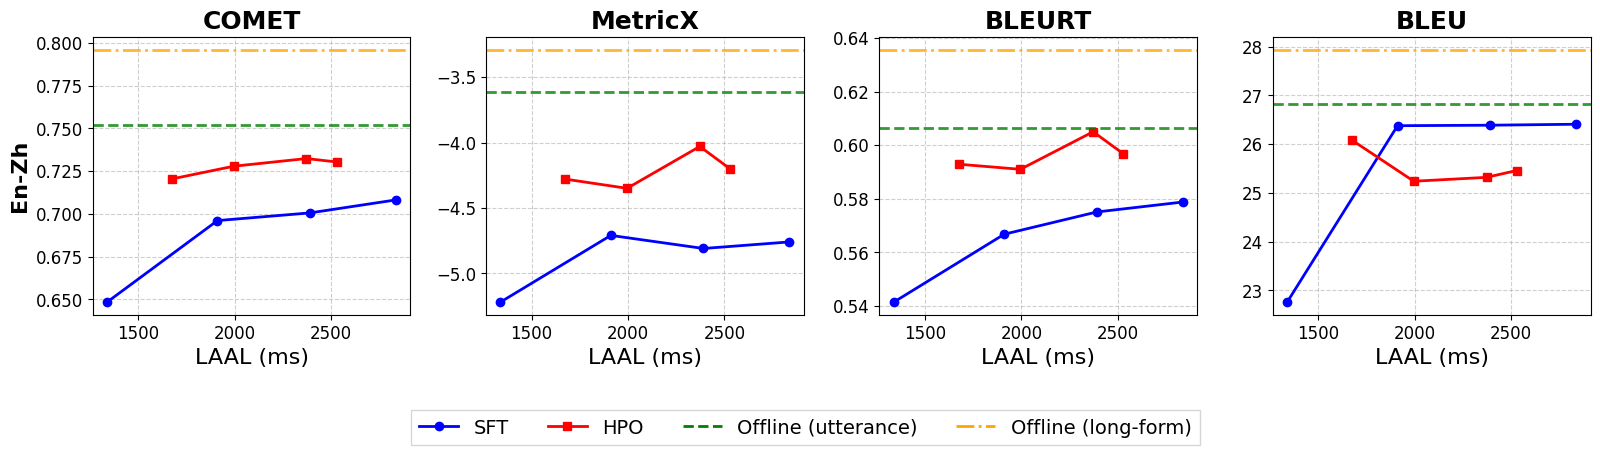

RealSI figure saved as 'plots/realsi_en_zh.pdf'
Figure structure: 1 row (En-Zh) x 4 columns (metrics)
Blue circles = SFT, Red squares = HPO
Green dashed lines = Offline (utterance), Orange dash-dot lines = Offline (long-form)


In [7]:
# Generate the RealSI figure
fig_realsi, axes_realsi = plot_realsi_figure(realsi_data, save_key="main_realsi")

print("RealSI figure saved as 'plots/realsi_en_zh.pdf'")
print("Figure structure: 1 row (En-Zh) x 4 columns (metrics)")
print("Blue circles = SFT, Red squares = HPO")
print("Green dashed lines = Offline (utterance), Orange dash-dot lines = Offline (long-form)")


# Reward Function Comparison - Bar Plot

In [96]:
def plot_reward_comparison_bars(data, save_key="reward_comparison"):
    """
    Plot reward function comparison as bar chart:
    - Different reward functions: SFT, HPO with Seed-X-RM, M-Prometheus, MQM, MetricX, VIP, COMET
    - 3 rows: En-Zh, En-De, En-Ja (language directions) 
    - 5 columns: COMET, MetricX, BLEURT, BLEU, VIP-Human (metrics)
    - Each subplot shows bars comparing different methods
    
    Data structure expected:
    data = {
        'En-Zh': {
            'SFT': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'HPO (Seed-X-RM)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'HPO (M-Prometheus)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'HPO (MQM)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'HPO (MetricX)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'HPO (VIP)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float},
            'HPO (COMET)': {'COMET': float, 'MetricX': float, 'BLEURT': float, 'BLEU': float, 'VIP-Human': float}
        },
        'En-De': { ... },
        'En-Ja': { ... }
    }
    """
    
    # Define the layout
    metrics = ["COMET", "MetricX", "BLEURT", "BLEU", "VIP-Human"] 
    languages = ["En-Zh"]
    methods = ["SFT", "HPO (Seed-X-RM)", "HPO (M-Prometheus)", "HPO (MQM)", "HPO (MetricX)", "HPO (VIP-LLM)", "HPO (COMET)"]
    
    # Create the figure with 3 rows and 5 columns
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), dpi=100)
    
    # Colors for the methods (distinguishable colors)
    colors = {
        'SFT': '#1f77b4',  # blue
        'HPO (Seed-X-RM)': '#ff7f0e',  # orange
        'HPO (M-Prometheus)': '#2ca02c',  # green
        'HPO (MQM)': '#d62728',  # red
        'HPO (MetricX)': '#9467bd',  # purple
        'HPO (VIP-LLM)': '#8c564b',  # brown
        'HPO (COMET)': '#e377c2'  # pink
    }
    
    # Plot each subplot
    for row, lang in enumerate(languages):
        for col, metric in enumerate(metrics):
            ax = axes[col]
            
            # Check if language data exists
            if lang in data:
                # Collect data for this metric
                method_names = []
                metric_values = []
                bar_colors = []
                
                for method in methods:
                    if method in data[lang] and metric in data[lang][method]:
                        method_names.append(method.replace('HPO (', '').replace(')', ''))  # Clean labels
                        metric_values.append(data[lang][method][metric])
                        bar_colors.append(colors[method])
                
                # Create bar plot
                if method_names and metric_values:
                    if metric == 'MetricX':
                        # For MetricX, set bottom to the minimum value so bars extend upward
                        bottom_val = min(metric_values) - 0.1 * abs(min(metric_values))
                        bars = ax.bar(range(len(method_names)), 
                                     [v - bottom_val for v in metric_values], 
                                     bottom=bottom_val,
                                     color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
                    else:
                        bars = ax.bar(range(len(method_names)), metric_values, 
                                     color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
                    
                    # Set x-axis labels
                    ax.set_xticks(range(len(method_names)))
                    ax.set_xticklabels(method_names, rotation=45, ha='right', fontsize=14)
            
            # Set only y-axis labels (no titles, no language labels)
            ax.set_ylabel(metric, fontsize=16, fontweight='bold')
            
            # Add grid and set tick label font sizes
            ax.grid(True, linestyle='--', alpha=0.3, axis='y')
            ax.tick_params(axis='y', which='major', labelsize=12)
            ax.tick_params(axis='x', which='major', labelsize=10)
            
            # Set y-axis to start from appropriate value (not always 0)
            if metric_values:
                y_min = min(metric_values)
                y_max = max(metric_values)
                y_range = y_max - y_min
                ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
                

    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(f"plots/{save_key}.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    return fig, axes


In [97]:
# Example data for reward function comparison (bar plot)
# Each method has a single value per metric (not LAAL curves)
reward_bar_data = {
    'En-Zh': {
        'SFT': {
            'COMET': 0.6484,
            'MetricX': -5.22,
            'BLEURT': 0.5415,
            'BLEU': 22.76,
        },
        'HPO (Seed-X-RM)': {
            'COMET': 0.7237,
            'MetricX': -4.64,
            'BLEURT': 0.5781,
            'BLEU': 19.95,
        },
        'HPO (M-Prometheus)': {
            'COMET': 0.6586,
            'MetricX': -5.15,
            'BLEURT': 0.5624,
            'BLEU': 16.94
        },
        'HPO (MQM)': {
            'COMET': 0.7047,
            'MetricX': -4.61,
            'BLEURT': 0.5853,
            'BLEU': 26.07,
            'VIP-Human': 75.3
        },
        'HPO (MetricX)': {
            'COMET': 0.7201,
            'MetricX': -4.31,
            'BLEURT': 0.5902,
            'BLEU': 26.76,
            'VIP-Human': 82.7
        },
        'HPO (VIP-LLM)': {
            'COMET': 0.721,
            'MetricX': -4.6,
            'BLEURT': 0.5785,
            'BLEU': 26.96,
            'VIP-Human': 68.4
        },
        'HPO (COMET)': {
            'COMET': 0.7122,
            'MetricX': -4.64,
            'BLEURT': 0.5766,
            'BLEU': 26.54,
            'VIP-Human': 77.9
        }
    },
}


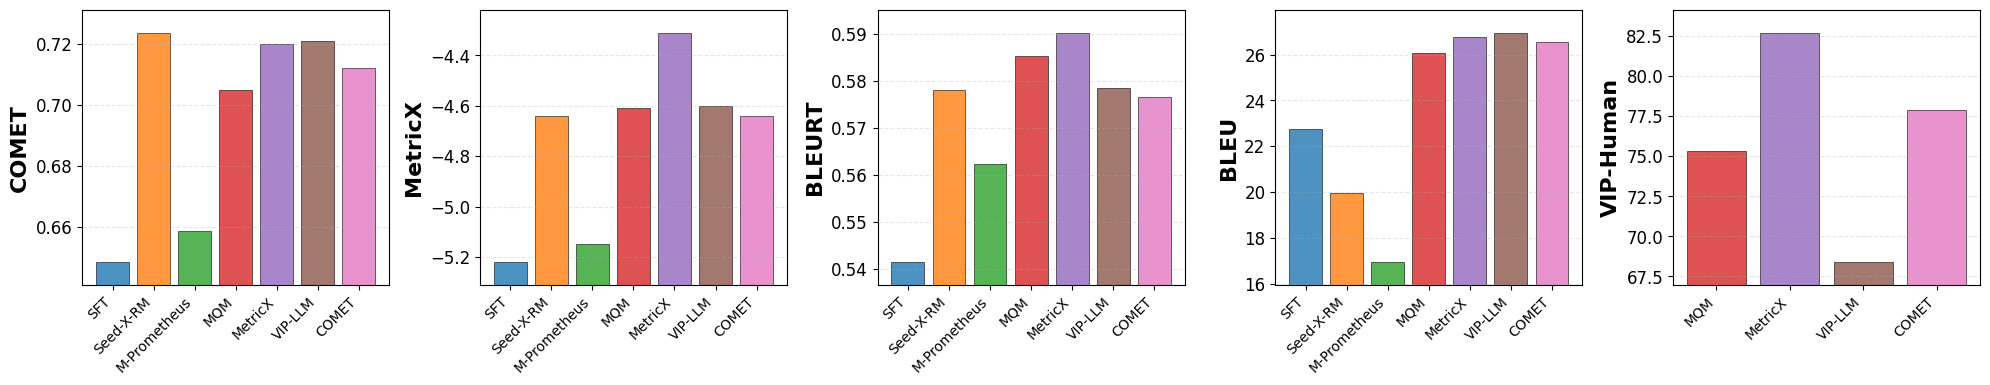

Reward comparison bar plot saved as 'plots/reward_comparison_bars.pdf'
Figure structure: 3 rows (language directions) x 4 columns (metrics)
Bar colors: SFT (blue), Seed-X-RM (orange), M-Prometheus (green), MQM (red)
            MetricX (purple), VIP (brown), COMET (pink)
Each subplot shows bars comparing all reward functions for that metric and language


In [98]:
# Generate the reward comparison bar plot
fig_reward_bars, axes_reward_bars = plot_reward_comparison_bars(reward_bar_data, save_key="reward_comparison_bars")

print("Reward comparison bar plot saved as 'plots/reward_comparison_bars.pdf'")
print("Figure structure: 3 rows (language directions) x 4 columns (metrics)")
print("Bar colors: SFT (blue), Seed-X-RM (orange), M-Prometheus (green), MQM (red)")
print("            MetricX (purple), VIP (brown), COMET (pink)")
print("Each subplot shows bars comparing all reward functions for that metric and language")


# Method Comparison Figure - 1x4 Curves


In [120]:
def plot_method_comparison_curves(data, save_key="method_comparison"):
    """
    Plot method comparison as curve chart:
    - 5 methods: HPO, HPO-doc, No-HPO, SeqPO, SFT
    - 1 row: Single language/dataset
    - 4 columns: COMET, MetricX, BLEURT, BLEU (metrics)
    - Each subplot shows curves comparing the 4 methods
    
    Data structure expected:
    data = {
        'HPO': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
        'HPO-doc': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
        'No-HPO': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
        'SeqPO': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]},
        'SFT': {'LAAL': [list], 'COMET': [list], 'MetricX': [list], 'BLEURT': [list], 'BLEU': [list]}
    }
    """
    
    # Define the layout
    metrics = ["COMET", "MetricX", "BLEURT", "BLEU"] 
    methods = ["HPO", "HPO-doc", "No-HPO", "SeqPO", "SFT"]
    
    # Create the figure with 1 row and 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=100)
    
    # Colors and styles for the methods
    colors = {
        'HPO': 'red',
        'HPO-doc': 'blue', 
        'No-HPO': 'green',
        'SeqPO': 'orange',
        'SFT': 'purple'
    }
    markers = {
        'HPO': 'o',
        'HPO-doc': 's', 
        'No-HPO': '^',
        'SeqPO': 'D',
        'SFT': 'x'
    }
    
    # Plot each subplot
    for col, metric in enumerate(metrics):
        ax = axes[col]
        
        # Plot each method
        for method in methods:
            if method in data:
                method_data = data[method]
                if 'LAAL' in method_data and metric in method_data:
                    laal_values = method_data['LAAL']
                    metric_values = method_data[metric]
                    
                    # Plot the curve
                    ax.plot(laal_values, metric_values, 
                           label=method, 
                           color=colors[method], 
                           marker=markers[method], 
                           markersize=6,
                           linewidth=2)
        
        # Set labels
        ax.set_ylabel(metric, fontsize=16, fontweight='bold')
        ax.set_xlabel('LAAL (ms)', fontsize=16)
        
        # Add grid and set tick label font sizes
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Adjust layout
    plt.tight_layout()
    
    # Create a single legend at the bottom center of the entire figure
    method_handles = []
    for method in methods:
        method_handles.append(plt.Line2D([0], [0], color=colors[method], marker=markers[method], 
                                       linestyle='-', markersize=6, linewidth=2, label=method))
    
    # Add the legend at the bottom center
    fig.legend(handles=method_handles, 
               loc='lower center', 
               bbox_to_anchor=(0.5, -0.15), 
               ncol=5, 
               fontsize=14,
               frameon=True,
               fancybox=False,
               shadow=False)
    
    # Adjust layout again to accommodate legend
    plt.subplots_adjust(bottom=0.2)
    
    # Save the figure
    plt.savefig(f"plots/{save_key}.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
    return fig, axes


In [127]:
# Example data for method comparison (curve plot)
method_comparison_data = {
    'HPO': {
        'LAAL': [1676, 1995, 2372, 2528],
        'COMET': [0.7205, 0.7279, 0.7324, 0.7304],
        'MetricX': [-4.28, -4.35, -4.03, -4.2],
        'BLEURT': [0.5929, 0.591, 0.605, 0.5968],
        'BLEU': [26.08, 25.24, 25.32, 25.46]
    },
    'HPO-doc': {
        'LAAL': [1831, 1971, 2428, 2682],
        'COMET': [0.6939, 0.7148, 0.7051, 0.7091],
        'MetricX': [-4.8, -4.21, -4.47, -4.61],
        'BLEURT': [0.5785, 0.5876, 0.5826, 0.5819],
        'BLEU': [24.68, 24.45, 25.68, 26.11]
    },
    'SeqPO': {
        'LAAL': [2186, 2494, 3150, 3985],
        'COMET': [0.6944, 0.7102, 0.7005, 0.7142],
        'MetricX': [-5.08, -4.3, -4.57, -4.49],
        'BLEURT': [0.5703, 0.5943, 0.5846, 0.5859],
        'BLEU': [25.38, 24.46, 25.06, 26.04]
    },
    'No-HPO': {
        'LAAL': [1557, 1913, 2320, 2588],
        'COMET': [0.6827, 0.7142, 0.7248, 0.7107],
        'MetricX': [-5, -4.39, -4.32, -4.44],
        'BLEURT': [0.5676, 0.5913, 0.5945, 0.584],
        'BLEU': [25.08, 24.94, 25.88, 24.9]
    },
    'SFT': {
        'LAAL': [1339, 1911, 2391, 2836],
        'COMET': [0.6484, 0.6961, 0.7006, 0.7082],
        'MetricX': [-5.22, -4.71, -4.81, -4.76],
        'BLEURT': [0.5415, 0.5668, 0.5751, 0.5788],
        'BLEU': [22.76, 26.38, 26.39, 26.41]
    }
}


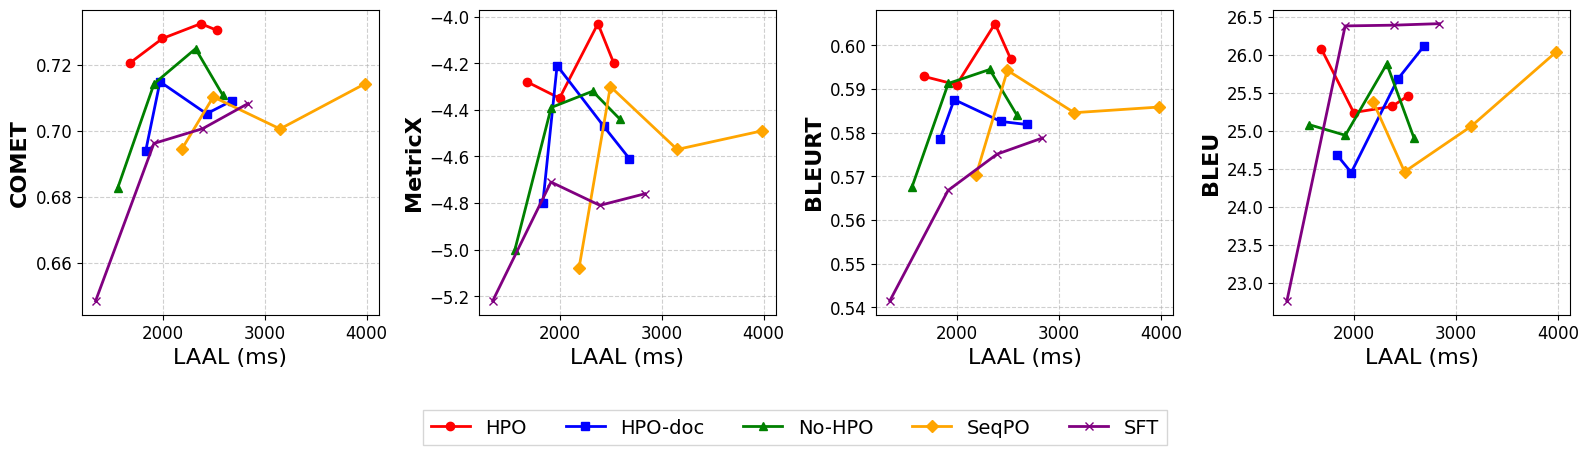

Method comparison figure saved as 'plots/method_comparison_curves.pdf'
Figure structure: 1 row x 4 columns (metrics)
Methods: HPO (red ●), HPO-doc (blue ■), No-HPO (green ▲), SeqPO (orange ◆), SFT (purple ✕)
Each subplot shows LAAL vs metric curves for all 5 methods


In [128]:
# Generate the method comparison curve figure
fig_methods, axes_methods = plot_method_comparison_curves(method_comparison_data, save_key="method_comparison_curves")

print("Method comparison figure saved as 'plots/method_comparison_curves.pdf'")
print("Figure structure: 1 row x 4 columns (metrics)")
print("Methods: HPO (red ●), HPO-doc (blue ■), No-HPO (green ▲), SeqPO (orange ◆), SFT (purple ✕)")
print("Each subplot shows LAAL vs metric curves for all 5 methods")
